# 作业4-5：CNN、RNN、Transformer 及 AI 辅助编程练习

## 1. 卷积神经网络

### 1.1 目标

通过对 MNIST 数据进行训练，构建一个简单的图像分类模型，对图片中的数字进行识别。你将利用该模型对自己真实手写出的数字进行预测，观察模型效果。

### 1.2 主要步骤

1. 获取数据
2. 定义模型结构
3. 创建模型类
4. 定义损失函数
5. 编写训练循环
6. 实施预测

### 1.3 获取数据

我们使用知名的 MNIST 数据集，它可以从 PyTorch 中利用工具函数下载得到。MNIST 数据训练集大小为60000，我们将**使用完整训练集进行训练**，并对10个测试集观测进行预测展示。以下函数会在当前目录建立一个名为 data 的文件夹，其中会包含下载得到的数据集。

**注意：请在任何程序的最开始加上随机数种子的设置。请保持这一习惯。**

In [2]:
import numpy as np
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

np.random.seed(123456)
torch.manual_seed(123456)

mnist = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist, batch_size=60000, shuffle=True)

100.0%
100.0%
100.0%
100.0%


我们一次性取出60000个观测，其中 x 是图片数据，y 是图片对应的数字。

In [3]:
x, y = next(iter(loader))

一个习惯性动作是查看数据的大小和维度。

In [ ]:



print(x.shape)
print(y.shape)

torch.Size([60000, 1, 28, 28])
torch.Size([60000])


用类似的方法获取测试集，并取出10个观测：

In [ ]:
mnist_test = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist_test, batch_size=10, shuffle=True)

xtest, ytest = next(iter(loader))
print(xtest.shape)
print(ytest.shape)

torch.Size([10, 1, 28, 28])
torch.Size([10])


我们可以利用下面的函数展示图片的内容。如选择第一张测试图片，先将其转换成 Numpy 数组，再绘制图形：

(28, 28)


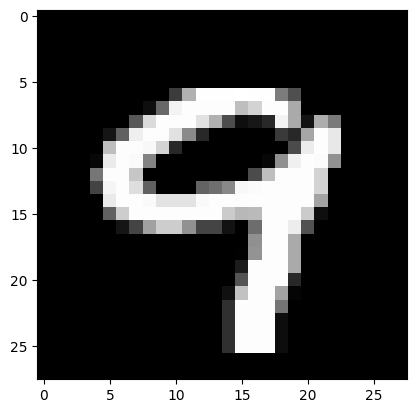

In [7]:
import matplotlib.pyplot as plt

img = xtest[0].squeeze().cpu().numpy()
print(img.shape)
plt.imshow(img, cmap="gray")
plt.show()

接下来请你选择5个你喜欢的数字（60000以下），然后取出训练集中对应位置的图片，并画出它们的内容。

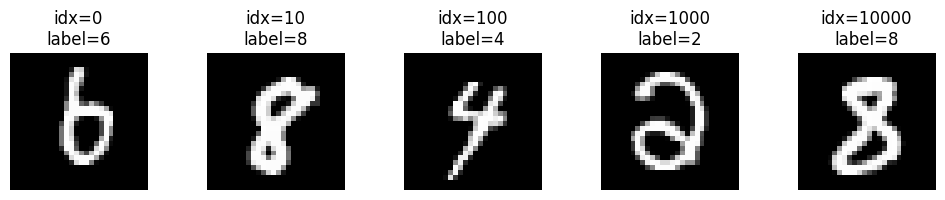

In [8]:

idxs = [0, 10, 100, 1000, 10000]

plt.figure(figsize=(10, 2))
for i, idx in enumerate(idxs):
    img = x[idx].squeeze().cpu().numpy()
    label = y[idx].item()

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"idx={idx}\nlabel={label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


### 1.4 定义模型结构

我们搭建一个类似于 LeNet-5 的网络，结构如下：

![](https://pic1.zhimg.com/80/v2-82eabb4c17e90d467197d013f7629f3c_720w.jpg)

我们需要创建2个卷积层、2个汇聚层和2个全连接层，**暂时忽略所有的激活函数**。所有隐藏层的函数细节都可以在[官方文档](https://pytorch.org/docs/stable/nn.html)中按分类找到。每一个隐藏层本质上都是将一个数组变换成另一个数组的函数，因此为了确认编写的模型是正确的，可以先用一个小数据进行测试，观察输入和输出的维度。例如，我们先取出前6个观测，此时输入的维度是 `[6, 1, 28, 28]`：

In [9]:
ns = 6
smallx = x[0:ns]
smally = y[0:ns]
print(smallx.shape)
print(smally.shape)

torch.Size([6, 1, 28, 28])
torch.Size([6])


接下来创建第1个卷积层，并测试输出的维度。注意到我们可以直接将隐藏层当成一个函数来调用。

In [10]:
conv1 = torch.nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)
res1 = conv1(smallx)
print(res1.shape)

torch.Size([6, 20, 24, 24])


可以看到，输出的维度为 `[20, 24, 24]`（不包括第1位的数据批次维度），与之前图中的结果吻合。

接下来，请按照图中提示编写层对象 `pool1`、`conv2`、`pool2`、`fc1` 和 `fc2`，并顺次测试输入与输出的维度，使其与上图匹配。注意，在将一个大小为 `[6, 50, 4, 4]` 的数组（假设叫 `somearray`）传递给 `fc1` 之前，需要先将其变形为只有两个维度的数组，做法是 `somearray.view(-1, 50 * 4 * 4)`，其中 -1 表示该位置的大小不变。也可以使用 `torch.flatten()` 函数并指定其中的 `start_dim` 参数（请搜索其对应的函数文档）。

```py
pool1 = ...
res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

conv2 = ...
res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

pool2 = ...
res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

fc1 = ...
res5 = fc1(res4.view(-1, 800))
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

fc2 = ...
res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"
```

In [11]:
pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

conv2 = torch.nn.Conv2d(in_channels=20, out_channels=50, kernel_size=5, stride=1)
res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

fc1 = torch.nn.Linear(in_features=50 * 4 * 4, out_features=500)
res5 = fc1(res4.view(-1, 50 * 4 * 4))
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

fc2 = torch.nn.Linear(in_features=500, out_features=10)
res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"


torch.Size([6, 20, 12, 12])
torch.Size([6, 50, 8, 8])
torch.Size([6, 50, 4, 4])
torch.Size([6, 500])
torch.Size([6, 10])


### 1.5 创建模型类

在确保隐藏层维度都正确后，将所有的隐藏层封装到一个模型类中，其中模型结构在 `__init__()` 中定义，具体的计算过程在 `forward()` 中实现。此时需要加入激活函数。在本模型中，**请在 `conv1`、`conv2` 和 `fc1` 后加入 ReLU 激活函数，并在 `fc2` 后加入 Softmax 激活函数**。

```py
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ...
        self.pool1 = ...
        self.conv2 = ...
        self.pool2 = ...
        self.fc1 = ...
        self.fc2 = ...

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        ...
        return x
```

In [12]:
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = torch.nn.Conv2d(in_channels=20, out_channels=50, kernel_size=5, stride=1)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(in_features=50 * 4 * 4, out_features=500)
        self.fc2 = torch.nn.Linear(in_features=500, out_features=10)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)

        x = x.view(x.shape[0], -1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.softmax(x, dim=1)
        return x


再次测试输入输出的维度是否正确。如果模型编写正确，输出的维度应该是 `[6, 10]`，且输出结果为0到1之间的概率值。

In [13]:
np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
pred = model(smallx)
print(pred.shape)
print()
print(pred)
print()
print(torch.sum(pred, dim=1))

torch.Size([6, 10])

tensor([[0.0975, 0.1003, 0.0987, 0.1080, 0.0927, 0.0913, 0.0983, 0.1060, 0.1013,
         0.1058],
        [0.0971, 0.1000, 0.1006, 0.1078, 0.0939, 0.0914, 0.1014, 0.1017, 0.1025,
         0.1037],
        [0.0958, 0.0996, 0.0984, 0.1092, 0.0932, 0.0923, 0.0984, 0.1066, 0.1022,
         0.1043],
        [0.0991, 0.1006, 0.0990, 0.1091, 0.0918, 0.0889, 0.0989, 0.1061, 0.1042,
         0.1021],
        [0.0954, 0.1004, 0.1015, 0.1071, 0.0943, 0.0922, 0.1017, 0.1023, 0.1027,
         0.1024],
        [0.0962, 0.1011, 0.0987, 0.1094, 0.0923, 0.0906, 0.0958, 0.1088, 0.1024,
         0.1048]], grad_fn=<SoftmaxBackward0>)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


`pred` 的每一行加总为1，其中每一个元素代表对应类别的预测概率。

我们还可以直接打印模型对象，观察隐藏层的结构：

In [14]:
print(model)

MyModel(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)


### 1.6 定义损失函数

对于分类问题，损失函数通常选取为负对数似然函数。在 PyTorch 中，可以使用 `torch.nn.NLLLoss` 来完成计算。其用法是先定义一个损失函数对象，然后在预测值和真实标签上调用该函数对象。注意：损失函数对象的第一个参数是预测概率的**对数值**，第二个参数是真实的标签。[文档说明](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)。

In [15]:
lossfn = torch.nn.NLLLoss()
lossfn(torch.log(pred), smally)

tensor(2.3102, grad_fn=<NllLossBackward0>)

### 1.7 编写训练循环

对于本数据，选取 mini-batch 大小为200，共遍历数据3遍，优化器选为 SGD，学习率为0.001。记录每个 mini-batch 下的损失函数值存放到列表 `losses_sgd` 中，然后画出损失函数的曲线。

In [ ]:
lossfn = torch.nn.NLLLoss()



def train_model(model, optimizer, x_data, y_data, nepoch, batch_size):
    losses = []
    n = x_data.shape[0]
    model.train()

    for epoch in range(nepoch):

        perm = torch.randperm(n)

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb = x_data[idx]
            yb = y_data[idx]

            pred = model(xb)

            loss = lossfn(torch.log(pred + 1e-8), yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        print(f"epoch {epoch + 1}/{nepoch}, loss = {losses[-1]:.4f}")

    return losses

lr = 0.001
nepoch = 3
batch_size = 200


torch.manual_seed(123456)
model_sgd = MyModel()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=lr)
losses_sgd = train_model(model_sgd, optimizer_sgd, x, y, nepoch, batch_size)

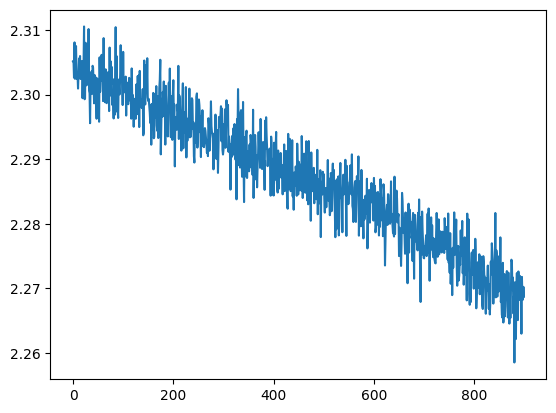

In [18]:
plt.plot(losses_sgd)

接下来使用 Adagrad 优化器（在[官方文档](https://pytorch.org/docs/stable/optim.html)中找到对应的函数），其他参数保持不变，重新训练一次模型，也保存下来损失函数值。

In [ ]:
torch.manual_seed(123456)
model_adagrad = MyModel()
optimizer_adagrad = torch.optim.Adagrad(model_adagrad.parameters(), lr=lr)
losses_adagrad = train_model(model_adagrad, optimizer_adagrad, x, y, nepoch, batch_size)

对比 SGD 和 Adagrad，画出各自的损失函数曲线。

In [ ]:
plt.plot(losses_sgd)
plt.plot(losses_adagrad)

最后再自行选择一款优化器，重复上面的实验，并画出三种优化器的损失函数值对比图。

In [ ]:
torch.manual_seed(123456)
model_adam = MyModel()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=lr)
losses_adam = train_model(model_adam, optimizer_adam, x, y, nepoch, batch_size)

plt.figure(figsize=(8, 5))
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_adagrad, label="Adagrad")
plt.plot(losses_adam, label="Adam")
plt.xlabel("mini-batch step")
plt.ylabel("loss")
plt.legend()
plt.title("Training loss comparison")
plt.show()


model = model_adam

### 1.8 实施预测

为了验证模型的效果，我们对10个测试观测（即之前生成的 `testx`）进行预测。

In [ ]:
model.eval()
with torch.no_grad():
    ypred = model(xtest)

print("预测概率矩阵：")
print(np.round(ypred.detach().cpu().numpy(), 3))
print("真实标签：")
print(ytest)
print("预测标签：")
print(torch.argmax(ypred, dim=1))

如果模型搭建和训练都正常，那么每一行中概率最大的取值所在的位置应该正好对应真实的标签。我们也可以让 PyTorch 自动找到最大值的位置。

In [ ]:
torch.argmax(ypred, dim=1)

最后，我们用模型对一些真实的手写数字图片进行预测。请你利用绘图软件（如 Windows 自带的绘图，或 Photoshop 等）准备10张正方形黑色底色的图片，每张用鼠标绘制一个数字（**请使用较粗的笔划**），从0到9，然后以0.png，1.png等文件名存储下来，放到当前目录一个名为 digits 的文件夹中。以下是几个例子：
![](digits/sample0.png) ![](digits/sample5.png) ![](digits/sample8.png)

接下来利用 Pillow 软件包读取图片：

In [ ]:
from PIL import Image
import os

sample_path = "digits/sample0.png"
if not os.path.exists(sample_path):
    sample_path = "digits/0.png"

if os.path.exists(sample_path):
    im = Image.open(sample_path)
    display(im)
else:
    im = None
    print("没有找到 digits/sample0.png 或 digits/0.png，演示图片读取步骤暂时跳过。")

此时如果直接将其转为 Numpy 数组会得到三个或四个通道（可能有一个透明度通道）：

In [ ]:
if im is not None:
    im_arr = np.array(im)
    print(im_arr.shape)
else:
    print("没有图片可转换。")

因此，我们先强制转换为灰度图片（单通道），再缩放至模型的图片大小 28 x 28：

In [ ]:
if im is not None:
    im = im.convert("L")
    im = im.resize((28, 28))
    im_arr = np.array(im)
    print(im_arr.shape)
    display(im)
else:
    print("没有图片可处理。")

为了传递给模型对象，还需要先将数值归一化到 [0,1] 区间，转换为 PyTorch 的 Tensor 类型，并增加一个批次和一个通道的维度：

In [ ]:
if im is not None:
    test0 = torch.tensor(im_arr / 255.0, dtype=torch.float32).view(1, 1, 28, 28)
    print(test0.shape)
else:
    test0 = None
    print("没有图片可转换为 Tensor。")

最后对图片标签进行预测：

In [ ]:
if test0 is not None:
    model.eval()
    with torch.no_grad():
        pred0 = model(test0)
    print(np.round(pred0.detach().cpu().numpy(), 3))
    print("预测数字：", torch.argmax(pred0, dim=1).item())
else:
    print("没有图片可预测。")

预测结果是否符合真实情形？请对你自己绘制出的10张图片进行类似的预测操作，并评价其效果。

In [ ]:
import os
from PIL import Image

model.eval()
results = []

plt.figure(figsize=(12, 5))

with torch.no_grad():
    for digit in range(10):
        path = f"digits/{digit}.png"

        if not os.path.exists(path):
            print(f"{path} 不存在，跳过。请先准备 {digit}.png")
            continue


        im = Image.open(path).convert("L").resize((28, 28))
        im_arr = np.array(im)






        test_img = torch.tensor(im_arr / 255.0, dtype=torch.float32).view(1, 1, 28, 28)

        pred = model(test_img)
        pred_label = torch.argmax(pred, dim=1).item()
        confidence = pred[0, pred_label].item()

        results.append((digit, pred_label, confidence))

        plt.subplot(2, 5, digit + 1)
        plt.imshow(im_arr, cmap="gray")
        plt.title(f"true={digit}\npred={pred_label}\nprob={confidence:.2f}")
        plt.axis("off")

plt.tight_layout()
plt.show()

if len(results) > 0:
    print("预测结果：")
    correct = 0
    for true_label, pred_label, confidence in results:
        correct += int(true_label == pred_label)
        print(f"真实数字 {true_label}，模型预测 {pred_label}，最高概率 {confidence:.3f}")
    print(f"10 张自制图片中实际读取到 {len(results)} 张，预测正确 {correct} 张，准确率 {correct / len(results):.2%}")
else:
    print("没有读取到自制数字图片。请在当前目录下创建 digits 文件夹，并放入 0.png 到 9.png 后重新运行本单元格。")

## 2. 循环神经网络

以 `names.txt` 中的英文名作为训练集，利用 RNN 或 LSTM 等方法对字母序列数据进行建模，每个字母视为序列中的一个元素，然后使用拟合的模型随机生成50个名字。本练习为开放式，不指定各类超参数（如网络结构、学习率、迭代次数等），但需提供必要的输出和诊断结果支持你的选择（如模型是否收敛、效果评价等）。

In [ ]:

import os
import random
import string
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(123456)
random.seed(123456)
torch.manual_seed(123456)
try:
    torch.set_num_threads(2)
except Exception:
    pass


def load_names():
    possible_paths = [
        "names.txt",
        "data/names.txt",
        "./names.txt",
    ]
    for p in possible_paths:
        if os.path.exists(p):
            with open(p, "r", encoding="utf-8") as f:
                raw_names = [line.strip() for line in f if line.strip()]
            print(f"从 {p} 读取到 {len(raw_names)} 个名字。")
            return raw_names

    print("没有找到 names.txt，下面使用备用英文名列表进行演示。正式提交时请把 names.txt 放在 notebook 同一目录下。")
    return [
        "James", "Mary", "John", "Patricia", "Robert", "Jennifer", "Michael", "Linda",
        "William", "Elizabeth", "David", "Barbara", "Richard", "Susan", "Joseph", "Jessica",
        "Thomas", "Sarah", "Charles", "Karen", "Christopher", "Nancy", "Daniel", "Lisa",
        "Matthew", "Betty", "Anthony", "Margaret", "Mark", "Sandra", "Donald", "Ashley",
        "Steven", "Kimberly", "Paul", "Emily", "Andrew", "Donna", "Joshua", "Michelle",
        "Kenneth", "Dorothy", "Kevin", "Carol", "Brian", "Amanda", "George", "Melissa",
        "Edward", "Deborah", "Ronald", "Stephanie", "Timothy", "Rebecca", "Jason", "Sharon",
        "Jeffrey", "Laura", "Ryan", "Cynthia", "Jacob", "Kathleen", "Gary", "Amy",
        "Nicholas", "Angela", "Eric", "Shirley", "Jonathan", "Anna", "Stephen", "Brenda",
        "Larry", "Pamela", "Justin", "Emma", "Scott", "Nicole", "Brandon", "Helen",
        "Benjamin", "Samantha", "Samuel", "Katherine", "Gregory", "Christine", "Alexander", "Debra",
        "Patrick", "Rachel", "Frank", "Catherine", "Raymond", "Carolyn", "Jack", "Janet",
        "Dennis", "Ruth", "Jerry", "Maria", "Tyler", "Heather", "Aaron", "Diane"
    ]

raw_names = load_names()
letters = set(string.ascii_lowercase)


names = []
for name in raw_names:
    clean = "".join(ch for ch in name.lower() if ch in letters)
    if len(clean) >= 2:
        names.append(clean)

names = sorted(set(names))
print("清洗后名字数量：", len(names))
print("前 10 个名字：", names[:10])


PAD, BOS, EOS = "<pad>", "<bos>", "<eos>"
chars = sorted(set("".join(names)))
itos = [PAD, BOS, EOS] + chars
stoi = {ch: i for i, ch in enumerate(itos)}

pad_id = stoi[PAD]
bos_id = stoi[BOS]
eos_id = stoi[EOS]
vocab_size = len(itos)
max_len = max(len(name) for name in names) + 2

print("字符表大小：", vocab_size)
print("最长序列长度：", max_len)


def encode_name(name):
    ids = [bos_id] + [stoi[ch] for ch in name] + [eos_id]
    ids = ids + [pad_id] * (max_len - len(ids))
    return ids

encoded = torch.tensor([encode_name(name) for name in names], dtype=torch.long)
X_name = encoded[:, :-1]
Y_name = encoded[:, 1:]
print("输入 X_name 形状：", X_name.shape)
print("目标 Y_name 形状：", Y_name.shape)


class NameLSTM(torch.nn.Module):
    def __init__(self, vocab_size, emb_dim=32, hidden_dim=96, num_layers=1):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.lstm = torch.nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = torch.nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(out)
        return logits, hidden


def train_name_model(model, X, Y, nepoch=60, batch_size=128, lr=0.003):
    criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_id)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    n = X.shape[0]

    for epoch in range(nepoch):
        model.train()
        perm = torch.randperm(n)
        epoch_losses = []

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb = X[idx]
            yb = Y[idx]

            logits, _ = model(xb)
            loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            losses.append(loss.item())
            epoch_losses.append(loss.item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"epoch {epoch + 1:3d}/{nepoch}, mean loss = {np.mean(epoch_losses):.4f}")

    return losses

torch.manual_seed(123456)
lstm_model = NameLSTM(vocab_size=vocab_size)
losses_lstm = train_name_model(lstm_model, X_name, Y_name, nepoch=50, batch_size=128, lr=0.003)

plt.figure(figsize=(8, 4))
plt.plot(losses_lstm)
plt.xlabel("mini-batch step")
plt.ylabel("loss")
plt.title("LSTM training loss")
plt.show()



def generate_names_lstm(model, n_names=50, max_new_chars=14, temperature=0.8):
    model.eval()
    current = torch.full((n_names, 1), bos_id, dtype=torch.long)
    hidden = None
    finished = torch.zeros(n_names, dtype=torch.bool)
    generated_ids = [[] for _ in range(n_names)]

    with torch.no_grad():
        for _ in range(max_new_chars):
            logits, hidden = model(current, hidden)
            logits = logits[:, -1, :] / temperature


            logits[:, pad_id] = -float("inf")
            logits[:, bos_id] = -float("inf")

            probs = torch.softmax(logits, dim=1)
            next_ids = torch.multinomial(probs, num_samples=1).squeeze(1)

            for i, next_id in enumerate(next_ids.tolist()):
                if finished[i]:
                    continue
                if next_id == eos_id:
                    finished[i] = True
                else:
                    generated_ids[i].append(next_id)


            next_ids = torch.where(finished, torch.full_like(next_ids, eos_id), next_ids)
            current = next_ids.unsqueeze(1)

    result = []
    for ids in generated_ids:
        name = "".join(itos[i] for i in ids).capitalize()

        if len(name) < 2:
            name = "Al"
        result.append(name)
    return result

generated_lstm = generate_names_lstm(lstm_model, n_names=50, temperature=0.8)

print("\nLSTM 随机生成的 50 个名字：")
for i, name in enumerate(generated_lstm, 1):
    print(f"{i:02d}. {name}")



## 3. Transformer

利用 Transformer 类型的网络架构，同样对 `names.txt` 中的英文名进行序列建模和训练，再使用拟合的模型随机生成50个名字。

Transformer 使用的训练姓名数： 48
输入 X_name 形状： torch.Size([48, 12])
目标 Y_name 形状： torch.Size([48, 12])
epoch   1/40, mean loss = 3.5466
epoch  10/40, mean loss = 2.8445
epoch  20/40, mean loss = 2.4973
epoch  30/40, mean loss = 2.1943
epoch  40/40, mean loss = 1.8937


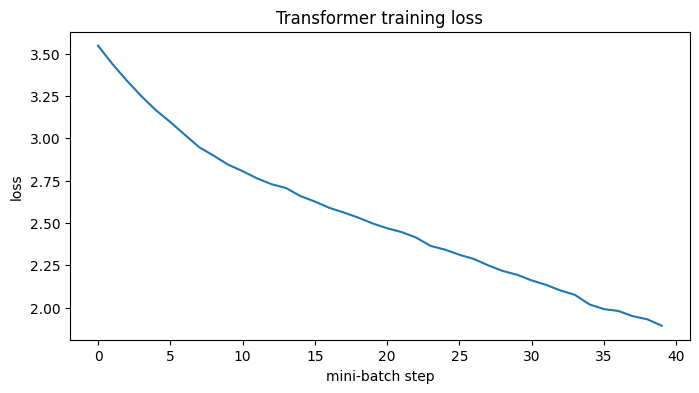


Transformer 随机生成的 50 个名字：
01. Menia
02. Jassa
03. Anthet
04. Jav
05. Matrpja
06. Pardrel
07. Jar
08. Mastheld
09. Eomhe
10. Eichar
11. Well
12. Danas
13. Jorhay
14. Jaris
15. Mathpoet
16. Meida
17. Nareb
18. Nary
19. Ross
20. Kevia
21. Mana
22. Einal
23. Josh
24. Kenndch
25. Nizdoli
26. Marenet
27. Saviajet
28. Maredosh
29. Dhos
30. Shristud
31. Mavevely
32. Jonl
33. Madoy
34. Vien
35. Eifetis
36. Mibichle
37. Emhe
38. Mhenl
39. Lichewy
40. Aumeres
41. Sark
42. Doliata
43. Menleleh
44. Soniy
45. Jonry
46. Risan
47. Jona
48. Iarich
49. Jlshn
50. Naniethhyer

效果评价：
Transformer 通过因果 mask 学习按顺序预测下一个字母，训练 loss 下降说明模型逐渐捕捉到了英文名中字母组合和结束位置的规律。
与 LSTM 相比，Transformer 不依赖递归隐状态，而是通过注意力机制综合利用已有字符，生成结果一般也能形成类似英文名的字符串。


In [ ]:

import math
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(123456)
torch.manual_seed(123456)
try:
    torch.set_num_threads(2)
except Exception:
    pass


if "X_name" not in globals() or "Y_name" not in globals():
    import os
    import string

    def load_names_for_transformer():
        possible_paths = ["names.txt", "data/names.txt", "./names.txt"]
        for p in possible_paths:
            if os.path.exists(p):
                with open(p, "r", encoding="utf-8") as f:
                    return [line.strip() for line in f if line.strip()]
        return [
            "James", "Mary", "John", "Patricia", "Robert", "Jennifer", "Michael", "Linda",
            "William", "Elizabeth", "David", "Barbara", "Richard", "Susan", "Joseph", "Jessica",
            "Thomas", "Sarah", "Charles", "Karen", "Christopher", "Nancy", "Daniel", "Lisa",
            "Matthew", "Betty", "Anthony", "Margaret", "Mark", "Sandra", "Donald", "Ashley",
            "Steven", "Kimberly", "Paul", "Emily", "Andrew", "Donna", "Joshua", "Michelle",
            "Kenneth", "Dorothy", "Kevin", "Carol", "Brian", "Amanda", "George", "Melissa"
        ]

    raw_names = load_names_for_transformer()
    letters = set(string.ascii_lowercase)
    names = []
    for name in raw_names:
        clean = "".join(ch for ch in name.lower() if ch in letters)
        if len(clean) >= 2:
            names.append(clean)
    names = sorted(set(names))

    PAD, BOS, EOS = "<pad>", "<bos>", "<eos>"
    chars = sorted(set("".join(names)))
    itos = [PAD, BOS, EOS] + chars
    stoi = {ch: i for i, ch in enumerate(itos)}
    pad_id = stoi[PAD]
    bos_id = stoi[BOS]
    eos_id = stoi[EOS]
    vocab_size = len(itos)
    max_len = max(len(name) for name in names) + 2

    def encode_name(name):
        ids = [bos_id] + [stoi[ch] for ch in name] + [eos_id]
        ids = ids + [pad_id] * (max_len - len(ids))
        return ids

    encoded = torch.tensor([encode_name(name) for name in names], dtype=torch.long)
    X_name = encoded[:, :-1]
    Y_name = encoded[:, 1:]

print("Transformer 使用的训练姓名数：", len(names))
print("输入 X_name 形状：", X_name.shape)
print("目标 Y_name 形状：", Y_name.shape)


class NameTransformer(torch.nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model=32, nhead=4, num_layers=1, dim_feedforward=64, dropout=0.1):
        super().__init__()
        self.token_embedding = torch.nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_embedding = torch.nn.Embedding(max_seq_len, d_model)

        encoder_layer = torch.nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="relu",
        )
        self.transformer = torch.nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = torch.nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)

        h = self.token_embedding(x) + self.position_embedding(positions)


        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, dtype=torch.bool, device=x.device),
            diagonal=1,
        )
        padding_mask = x.eq(pad_id)

        out = self.transformer(h, mask=causal_mask, src_key_padding_mask=padding_mask)
        logits = self.fc(out)
        return logits


def train_transformer_model(model, X, Y, nepoch=40, batch_size=128, lr=0.003):
    criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_id)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    n = X.shape[0]

    for epoch in range(nepoch):
        model.train()
        perm = torch.randperm(n)
        epoch_losses = []

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb = X[idx]
            yb = Y[idx]

            logits = model(xb)
            loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            losses.append(loss.item())
            epoch_losses.append(loss.item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"epoch {epoch + 1:3d}/{nepoch}, mean loss = {np.mean(epoch_losses):.4f}")

    return losses

torch.manual_seed(123456)
transformer_model = NameTransformer(vocab_size=vocab_size, max_seq_len=X_name.shape[1])
losses_transformer = train_transformer_model(transformer_model, X_name, Y_name, nepoch=40, batch_size=128, lr=0.003)

plt.figure(figsize=(8, 4))
plt.plot(losses_transformer)
plt.xlabel("mini-batch step")
plt.ylabel("loss")
plt.title("Transformer training loss")
plt.show()


def generate_names_transformer(model, n_names=50, max_new_chars=14, temperature=0.8):
    model.eval()
    ids = torch.full((n_names, 1), bos_id, dtype=torch.long)
    finished = torch.zeros(n_names, dtype=torch.bool)
    generated_ids = [[] for _ in range(n_names)]

    with torch.no_grad():
        for _ in range(max_new_chars):
            logits = model(ids)
            logits = logits[:, -1, :] / temperature


            logits[:, pad_id] = -float("inf")
            logits[:, bos_id] = -float("inf")

            probs = torch.softmax(logits, dim=1)
            next_ids = torch.multinomial(probs, num_samples=1).squeeze(1)

            for i, next_id in enumerate(next_ids.tolist()):
                if finished[i]:
                    continue
                if next_id == eos_id:
                    finished[i] = True
                else:
                    generated_ids[i].append(next_id)

            next_ids = torch.where(finished, torch.full_like(next_ids, eos_id), next_ids)
            ids = torch.cat([ids, next_ids.unsqueeze(1)], dim=1)


            if ids.shape[1] >= X_name.shape[1]:
                break

    result = []
    for one_ids in generated_ids:
        name = "".join(itos[i] for i in one_ids).capitalize()
        if len(name) < 2:
            name = "An"
        result.append(name)
    return result

generated_transformer = generate_names_transformer(transformer_model, n_names=50, temperature=0.8)

print("\nTransformer 随机生成的 50 个名字：")
for i, name in enumerate(generated_transformer, 1):
    print(f"{i:02d}. {name}")



## 4. AI 辅助编程工具实战

利用 OpenCode、Claude Code 等 AI 辅助编程工具完成一个小项目的实践，建议贴近日常生活，发挥自己的创意，如编写一个 HTML 小游戏、制作一份个人简历等，主题不限。请把你完成项目的过程录制成一段视频，重点体现你和 Coding Agent 的交互，完成后将视频文件传到 Canvas 中进行提交。